In [3]:
# CREAZIONE CLASSE FEEDFORWARD NEURAL NETWORK 


# Metodi della classe:


# sizes = [input_layer, hidden_layer1, hidden_layer2, ..., output_layer]
# output_activation: 'sigmoid' = sigmoide, 'linear' = lineare, 'relu' = ReLU, 'tanh' = Tangente iperbolica, 'softmax' = Softmax
# hidden_activation: 'sigmoid'= sigmoide, 'relu' = ReLU, 'tanh' = Tangente iperbolica
# loss_type: 'mse' = Mean Squared Error, 'mae' = Mean Absolute Error, 'cross_entropy' = Cross Entropy


# Adam: implementazione dell'ottimizzatore Adam con parametri di default (eta=0.07, betas=(0.9, 0.999), epsilon=1e-8)
# sgd: implementazione della Stochastic Gradient Descent con mini-batch e schedulatore del learning rate


import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

class feedforwardNN:
    def __init__(self, sizes, output_activation='sigmoid',hidden_activation='relu',loss_type='mse'):
        self.hidden_activation = hidden_activation
        self.output_activation = output_activation
        self.sizes = sizes
        self.num_layers = len(sizes)
        # Inizializzazione a 0 per i bias
        self.biases = [np.zeros((y, 1)) for y in sizes[1:]]
        # Inizializzazione di Xavier/Glorot (fondamentale per non saturare le sigmoidi nei layer nascosti)
        self.weights = [np.random.randn(y, x) * np.sqrt(1.0 / x) for x, y in zip(sizes[:-1], sizes[1:])]
        self.loss_type = loss_type

    def activation(self, z, der=0):
        """Calcola l'attivazione o la sua derivata in base al tipo."""
        if self.output_activation == 'sigmoid':
            sz = 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
            if der==1:
                sz = sz*(1-sz)
        elif self.output_activation == 'linear':
            sz = z
            if der==1:
                sz = np.ones_like(z)
        elif self.output_activation == 'relu':
            sz = np.maximum(0, z)
            if der==1:
                sz = (z > 0).astype(float)
        elif self.output_activation == 'tanh':
            sz = np.tanh(z)
            if der==1:
                sz = 1 - sz**2
        elif self.output_activation == 'softmax':
            exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))  # Stabilizzazione numerica
            sz = exp_z / np.sum(exp_z, axis=0, keepdims=True)
            if der==1:
                sz = sz*(1 - sz)
        else:
            raise ValueError(f"Activation {self.output_activation} not supported.")
        return sz
    
    def feedforward(self, x):
        # Assicuriamoci che x sia un vettore colonna (shape: n x 1)
        x = x.reshape(-1, 1)
        a = [x]
        z = []
        
        for b, w in zip(self.biases[:-1], self.weights[:-1]):
            z.append(np.dot(w, a[-1]) + b)
            
            if self.hidden_activation == 'sigmoid':
                a.append(1.0 / (1.0 + np.exp(-np.clip(z[-1], -500, 500))))
            elif self.hidden_activation == 'relu':
                a.append(np.maximum(0, z[-1]))
            elif self.hidden_activation == 'tanh':
                a.append(np.tanh(z[-1]))
            else:
                raise ValueError(f"Hidden activation {self.hidden_activation} not supported.")
            
        # Output layer
        z.append(np.dot(self.weights[-1], a[-1]) + self.biases[-1])
        a.append(self.activation(z[-1])) 
        
        return a, z
    
    def Adam(self, training_set, epochs, mini_batch_size=32, eta=0.07, betas=(0.9, 0.999), epsilon=1e-8, test_set=None, plot_progress=False):
        # Evitiamo di mescolare il dataset originale (Side Effect) copiandolo superficialmente
        training_set = training_set.copy()
        test_set_provided = test_set is not None
        
        # Disabilita il plot in tempo reale per dati multi-dimensionali (es. classificazione) per evitare crash
        if plot_progress and test_set_provided:
            if test_set[0][0].shape[0] != 1 or test_set[0][1].shape[0] != 1:
                print("Avviso: Il plot in tempo reale è supportato solo per task 1D. Verrà disabilitato per questo task.")
                plot_progress = False

        if test_set_provided and plot_progress: 
            x_plot = np.array([item[0] for item in test_set]).flatten()
            y_test_arr = np.array([item[1] for item in test_set]).flatten()
            test_set_denorm = [(item[0], y_i * (np.max(y_test_arr) - np.min(y_test_arr)) + np.min(y_test_arr)) for item, y_i in zip(test_set, y_test_arr)]
            plt.ion()
            cost_vector = np.zeros(epochs + 1)
            
            fig, (ax, ax_pred) = plt.subplots(1, 2, figsize=(14, 6))
            
            cost_vector[0] = self.__evaluate(test_set)
            cost_line, = ax.plot(0, cost_vector[0], 'b-', label='Costo su test set')
            ax.set_xlabel('Epoche', fontsize=12, fontweight='bold')
            ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
            ax.set_xlim(0, epochs)
            ax.set_ylim(0, cost_vector[0] * 1.1)
            ax.legend()
            
            y_plot = np.array([item[1] for item in test_set_denorm]).flatten()
            ax_pred.scatter(x_plot, y_plot, c='blue', label='Dati', alpha=0.5)
            _, initial_preds = self.get_predictions(test_set_denorm)
            pred_scatter = ax_pred.scatter(x_plot, initial_preds, c='red', label='Predizioni MLP', alpha=0.7)
            
            ax_pred.set_title('Evoluzione MLP', fontweight='bold')
            ax_pred.set_xlabel('x')
            ax_pred.set_ylabel('y')
            ax_pred.legend()
            ax_pred.grid(True)
            fig.tight_layout()

        mw = [np.zeros(w.shape) for w in self.weights]
        mb = [np.zeros(b.shape) for b in self.biases]
        vw = [np.zeros(w.shape) for w in self.weights] 
        vb = [np.zeros(b.shape) for b in self.biases]
        
        t = 0
        n = len(training_set)
        barra_epoche = tqdm(range(epochs), desc="Addestramento Adam")
        loss = []
        if test_set_provided:
            cost_vector = np.zeros(epochs + 1)
            cost_vector[0] = self.__evaluate(test_set)
            plt.ion()
            fig = plt.figure()
            ax = plt.gca()
            # Aggiunge titolo e etichette
            plt.title('Grafico della rete')
            ax.set_xlabel('numero di epoche')
            ax.set_ylabel('funzione costo')
            ax.set_xlim(0,epochs)
            ax.set_ylim(0,cost_vector[0])  
            ax.legend()
            cost_line, = ax.plot(0, cost_vector[0], 'b-', label='Loss sul test set')
            
        for j in barra_epoche:
            np.random.shuffle(training_set)
            for k in range(0, n, mini_batch_size):
                mini_batch = training_set[k:k+mini_batch_size]
                batch_size = len(mini_batch)
                nabla_b = [np.zeros(b.shape) for b in self.biases]
                nabla_w = [np.zeros(w.shape) for w in self.weights]
                
                for x, y in mini_batch:
                    # Usiamo 1.0 / batch_size come 'etam' per ottenere il gradiente medio del batch
                    delta_nabla_b, delta_nabla_w = self.__backpropagation(x, y, 1.0 / batch_size)
                    nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
                    nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]    
                t += 1
                for i in range(len(self.weights)):
                    mw[i] = betas[0] * mw[i] + (1 - betas[0]) * nabla_w[i]
                    mb[i] = betas[0] * mb[i] + (1 - betas[0]) * nabla_b[i]
                    vw[i] = betas[1] * vw[i] + (1 - betas[1]) * (nabla_w[i]**2)
                    vb[i] = betas[1] * vb[i] + (1 - betas[1]) * (nabla_b[i]**2)
                    
                    mw_hat = mw[i] / (1 - betas[0]**t)
                    mb_hat = mb[i] / (1 - betas[0]**t)
                    vw_hat = vw[i] / (1 - betas[1]**t)
                    vb_hat = vb[i] / (1 - betas[1]**t)
                    
                    self.weights[i] -= eta * mw_hat / (np.sqrt(vw_hat) + epsilon)
                    self.biases[i] -= eta * mb_hat / (np.sqrt(vb_hat) + epsilon)
            
            # Valutazione a fine epoca
            current_dataset = test_set if test_set_provided else training_set
            current_loss = self.__evaluate(current_dataset)
            loss.append(current_loss)
            barra_epoche.set_postfix(Loss=f"{current_loss:.6f}")
            
            if test_set_provided:
                cost_vector[j+1] = current_loss
                if j % 10 == 0:  
                    cost_line.set_data(range(j+2), cost_vector[:j+2])
                    ax.set_ylim(0, max(cost_vector[:j+2]) * 1.1)
                    if plot_progress:
                        _, y_pred = self.get_predictions(test_set_denorm)
                        new_offsets = np.c_[x_plot, y_pred] 
                        pred_scatter.set_offsets(new_offsets)
                    fig.canvas.draw()
                    fig.canvas.flush_events()
                    
        barra_epoche.close()
        if test_set_provided:
            plt.ioff()
            plt.show()
                    

    def sgd(self, training_set, epochs, mini_batch_size, eta, test_set=None, plot_progress=True):
        # Evitiamo di mescolare il dataset originale (Side Effect) copiandolo superficialmente
        training_set = training_set.copy()
        test_set_provided = test_set is not None
        
        # Disabilita il plot in tempo reale per dati multi-dimensionali (es. classificazione) per evitare crash
        if plot_progress and test_set_provided:
            if test_set[0][0].shape[0] != 1 or test_set[0][1].shape[0] != 1:
                print("Avviso: Il plot in tempo reale è supportato solo per task 1D. Verrà disabilitato per questo task.")
                plot_progress = False
    
        if test_set_provided and plot_progress: 
            x_plot = np.array([item[0] for item in test_set]).flatten()
            y_test_arr = np.array([item[1] for item in test_set]).flatten()
            test_set_denorm = [(item[0], y_i * (np.max(y_test_arr) - np.min(y_test_arr)) + np.min(y_test_arr)) for item, y_i in zip(test_set, y_test_arr)]
            plt.ion()
            cost_vector = np.zeros(epochs + 1)
            
            # Creiamo una singola figura con due grafici affiancati (1 riga, 2 colonne)
            fig, (ax, ax_pred) = plt.subplots(1, 2, figsize=(14, 6))
            
            # --- Configurazione Grafico 1: Loss ---
            cost_vector[0] = self.__evaluate(test_set)
            cost_line, = ax.plot(0, cost_vector[0], 'b-', label='Costo su test set')
            ax.set_xlabel('Epoche', fontsize=12, fontweight='bold')
            ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
            ax.set_xlim(0, epochs)
            ax.set_ylim(0, cost_vector[0] * 1.1)
            ax.legend()
            
            # --- Configurazione Grafico 2: Regressione ---
            y_plot = np.array([item[1] for item in test_set_denorm]).flatten()
            
            # Plottiamo i dati reali UNA sola volta (sono statici)
            ax_pred.scatter(x_plot, y_plot, c='blue', label='Dati', alpha=0.5)
            
            # Inizializziamo lo scatter plot delle predizioni (otteniamo le predizioni iniziali pre-training)
            _, initial_preds = self.get_predictions(test_set_denorm)
            # Salviamo l'oggetto PathCollection restituito da scatter nella variabile pred_scatter
            pred_scatter = ax_pred.scatter(x_plot, initial_preds, c='red', label='Predizioni MLP', alpha=0.7)
            
            ax_pred.set_title('Evoluzione MLP per Regressione', fontweight='bold')
            ax_pred.set_xlabel('x')
            ax_pred.set_ylabel('y')
            ax_pred.legend()
            ax_pred.grid(True)
            
            # Mostriamo la struttura iniziale
            fig.tight_layout()


        n = len(training_set)
        barra_epoche = tqdm(range(epochs), desc="Addestramento MLP")
        if test_set_provided:
            cost_vector = np.zeros(epochs + 1)
            cost_vector[0] = self.__evaluate(test_set)
            plt.ion()
            fig = plt.figure()
            ax = plt.gca()
            # Aggiunge titolo e etichette
            plt.title('Grafico della rete')
            ax.set_xlabel('numero di epoche')
            ax.set_ylabel('funzione costo')
            ax.set_xlim(0,epochs)
            ax.set_ylim(0,cost_vector[0])  
            ax.legend()
            cost_line, = ax.plot(0, cost_vector[0], 'b-', label='Loss sul test set')
            
        for j in barra_epoche:
            np.random.shuffle(training_set)
            
            for k in range(0, n, mini_batch_size):
                mini_batch = training_set[k:k+mini_batch_size]
                self.__update_mini_batch(mini_batch, eta)
                
            if test_set_provided:
                cost_vector[j+1] = self.__evaluate(test_set)
                barra_epoche.set_postfix(Loss=f"{cost_vector[j+1]:.6f}")
                
                # Schedulatore del learning rate
                if cost_vector[j+1] > 1.2 * cost_vector[j]:
                    eta = max(eta * 0.9, 1e-8)
                elif cost_vector[j+1] < 0.8 * cost_vector[j]:
                    eta = min(eta * 1.1, 1e3)
                
                if j % 10 == 0:  
                    # 1. Aggiornamento del grafico della Loss
                    cost_line.set_data(range(j+2), cost_vector[:j+2])
                    ax.set_ylim(0, max(cost_vector[:j+2]) * 1.1)

                    if plot_progress:
                        # 2. Aggiornamento del grafico di Regressione
                        _, y_pred = self.get_predictions(test_set)
                        # set_offsets richiede un array 2D di coordinate (x, y) per ogni punto
                        new_offsets = np.c_[x_plot, y_pred] 
                        pred_scatter.set_offsets(new_offsets)
                    fig.canvas.draw()
                    fig.canvas.flush_events()
                
        barra_epoche.close()
        print("Training completato!")
        
        if test_set_provided:
            plt.ioff()
            plt.show() # Mantiene i grafici aperti a fine addestramento
    
    
    def __update_mini_batch(self, mini_batch, eta):
        m = len(mini_batch)
        etam = eta / m
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.__backpropagation(x, y, etam)
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            
        self.weights = [w - nw for w, nw in zip(self.weights, nabla_w)]
        self.biases = [b - nb for b, nb in zip(self.biases, nabla_b)]
      
        
    def __backpropagation(self, x, y, etam):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        a, z = self.feedforward(x)
        y = y.reshape(-1, 1)
        # Assicuriamoci che y sia un vettore colonna comparabile con a[-1]
        
        # Calcolo dell'errore all'output layer in base all'attivazione scelta
        if self.output_activation == 'softmax' and self.loss_type == 'cross entropy':
            # La derivata matematica combinata di Cross-Entropy + Softmax rispetto ai logits (z) è (a - y)
            delta = a[-1] - y
        elif self.output_activation == 'sigmoid' and self.loss_type == 'cross entropy':
            # Anche per la Binary Cross-Entropy combinata alla Sigmoide, la derivata si semplifica in (a - y)
            delta = a[-1] - y
        else:
            delta = self.__cost_derivative(a[-1], y) * self.activation(z[-1],der=1)
        
        nabla_b[-1] = etam * delta
        nabla_w[-1] = etam * np.dot(delta, a[-2].transpose())
        # Backpropagation nei layer nascosti in base all'attivazione scelta
        for l in range(2, self.num_layers):
            z_l = z[-l]
            if self.hidden_activation == 'sigmoid':
                sig = 1.0 / (1.0 + np.exp(-np.clip(z_l, -500, 500)))
                sp = sig * (1 - sig)  # Derivata del sigmoide
            elif self.hidden_activation == 'relu':
                sp = (z_l > 0).astype(float) # Derivata della ReLU
            elif self.hidden_activation == 'tanh':
                sp = 1.0 - np.tanh(z_l)**2
                
            delta = np.dot(self.weights[-l+1].transpose(), delta) * sp
            nabla_b[-l] = etam * delta
            nabla_w[-l] = etam * np.dot(delta, a[-l-1].transpose()) 
            
        return (nabla_b, nabla_w)
    
    
    def __cost_derivative(self, output_activations, y):
        # Default per MSE
        if self.loss_type == 'mse':
            der = (output_activations - y)
        elif self.loss_type == 'mae':
            # La derivata matematica per la loss Absolute Error (L1)
            der =  np.sign(output_activations - y)
        elif self.loss_type == 'cross entropy':
            der = y/(output_activations+1e-10)
        else:
            raise ValueError(f"Loss type {self.loss_type} not supported.")
        return der
    
    
    def __evaluate(self, test_data):
        if self.loss_type == 'mse':
            loss = 0.5 * sum(np.linalg.norm(self.feedforward(x)[0][-1] - y.reshape(-1,1))**2 for x, y in test_data) / len(test_data)
        elif self.loss_type == 'mae':
            loss = sum(np.sum(np.abs(self.feedforward(x)[0][-1] - y.reshape(-1,1))) for x, y in test_data) / len(test_data)
        elif self.loss_type == 'cross entropy':
            loss = -sum(np.sum(y.reshape(-1,1) * np.log(self.feedforward(x)[0][-1] + 1e-10)) for x, y in test_data) / len(test_data)
        else:
            raise ValueError(f"Loss type {self.loss_type} not supported.")
        return loss


    def get_predictions(self, data_set):
        y_true = []
        y_pred = []
        for x, y in data_set:
            y_true.append(y.flatten())
            pred = self.feedforward(x)[0][-1].flatten()
            y_pred.append(pred)
            
        return y_true, y_pred

def cross_validation(data_set, k_folds=5):
    np.random.shuffle(data_set)
    fold_size = len(data_set) // k_folds
    folds = [data_set[i*fold_size:(i+1)*fold_size] for i in range(k_folds)]
    
    for i in range(k_folds):
        test_fold = folds[i]
        train_folds = [folds[j] for j in range(k_folds) if j != i]
        train_fold = [item for sublist in train_folds for item in sublist]
        yield train_fold, test_fold

In [4]:
# CREAZIONE CLASSE PER LA RETE NEURALE CONVULAZIONALE (PYTORCH)


import torch.nn as nn

class CNN(nn.Module):
    def __init__(self,in_var=1, out_var=32,classes=10, kernel_size=3, padding=1,stride=2, epochs = 21):
        # 1. Inizializza la classe genitore
        super(CNN, self).__init__()
        self.in_channels = in_var # in_channels: 1 per immagini in scala di grigi, 3 per immagini RGB (a colori)
        self.out_channels = out_var # out_channels: numero di filtri/feature map che vuoi applicare
        self.kernel_size = kernel_size # kernel_size: dimensione della finestra (es. 3x3)
        self.padding = padding
        self.stride= stride
        self.epochs = epochs
        
        self.in_features = self.out_channels *((self.stride)**2) *(self.stride**2)
        # Il numero di in_features dipende dalla dimensione dell'immagine 
        # dopo i 3 layer convoluzionali e di pooling. 
        # Per immagini 32x32, dopo tre layer MaxPool 2x2 diventerà 4x4.
        # Quindi in_features = 32 (canali) * 4 (altezza) * 4 (larghezza) = 512
        self.out_features = classes
        # Output finale: 10 classi (es. cifre da 0 a 9)    
            
            
        # 2. Definisci il blocco di estrazione delle feature (Convoluzioni)
        # nn.Sequential è comodissimo per raggruppare layer eseguiti in cascata
        self.blocco_convoluzionale = nn.Sequential(
            nn.Conv2d(in_channels=self.in_channels, out_channels=self.out_channels, kernel_size=self.kernel_size, padding=self.padding),
            nn.ReLU(), # Funzione di attivazione
            nn.MaxPool2d( kernel_size= self.kernel_size-1, stride=self.stride),
            # Riduce le dimensioni spaziali dell'immagine (es. dimezza altezza e larghezza)
            
            # Puoi impilare altri layer convoluzionali
            nn.Conv2d(in_channels=self.out_channels, out_channels=self.out_channels, kernel_size=self.kernel_size, padding=self.padding),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= self.kernel_size-1, stride=self.stride),
            
            nn.Conv2d(in_channels=self.out_channels, out_channels=self.out_channels, kernel_size=self.kernel_size, padding=self.padding),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= self.kernel_size-1, stride=self.stride)
        )
        
        # 3. Definisci il blocco di classificazione (Multi-Layer Perceptron)
        self.blocco_classificatore = nn.Sequential(
            # Appiattisce le feature map 2D in un vettore 1D
            nn.Flatten(), 
            nn.Linear(self.in_features, int(self.in_features/2)),
            nn.ReLU(),
            nn.Linear(int(self.in_features/2), self.out_features)
        )

    def forward(self, x):
        # Specifica il percorso dei dati in input (x)
        x = self.blocco_convoluzionale(x)
        x = self.blocco_classificatore(x)
        # Nota: solitamente in PyTorch non si applica la Softmax qui 
        # perché è inclusa direttamente nella funzione di loss (nn.CrossEntropyLoss)
        return x
    def train_model(self, train_loader, optimizer, criterion, device):
        self.train()  # Imposta il modello in modalità training
        for epoch in range(self.epochs):
            epoch_loss = self.train_epoch(train_loader, optimizer, criterion, device)
            print(f'Epoca {epoch+1}/{self.epochs}, Loss: {epoch_loss:.4f}')

            
    def train_epoch(self, train_loader, optimizer, criterion, device):
        self.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()  # Azzerare i gradienti
            
            outputs = self.forward(images)  # Passaggio forward
            loss = criterion(outputs, labels)  # Calcolare la loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Aggiornare i pesi
            
            total_loss += loss.item()
        print(f'Loss media: {total_loss / len(train_loader):.4f}')
        return total_loss / len(train_loader)


In [5]:
# CREAZIONE CLASSE PER CARICARE IL DATASET SPOT10 (MNIST PERSONALIZZATO) IN FORMATO IDX


import gzip
import numpy as np
import struct
import os
from array import array

class SPOT10Loader:
    def __init__(self):
        pass

    @staticmethod
    def get_data(dataset_dir, kind='train'):
        """Load custom MNIST data from `path`"""
        labels_path = os.path.join(dataset_dir, f'{kind}-labels-idx1-ubyte.gz')
        images_path = os.path.join(dataset_dir, f'{kind}-images-idx3-ubyte.gz')

        with gzip.open(labels_path, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())

        with gzip.open(images_path, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())

        images = np.zeros((size, rows, cols), dtype=np.uint8)
        for i in range(size):
            images[i] = np.array(image_data[i * rows * cols:(i + 1) * rows * cols]).reshape(rows, cols)

        return np.array(images), np.array(labels)


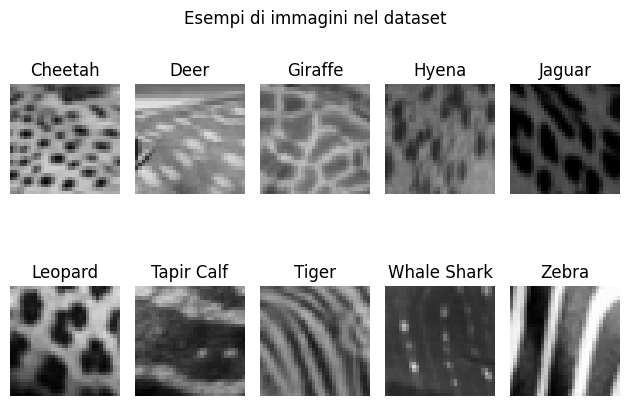

Le immagini hanno dimensione: 32x32
Il numero di classi è: 10


In [6]:
# IMPORTAZIONE E PREPROCESSAMENTO DEI DATI PER CLASSIFICAZIONE DI IMMAGINI 


import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import OneHotEncoder
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import random
import pickle
import itertools



script_dir = os.getcwd()+'\dati'  # Ottiene il percorso della directory corrente

# Impostazione del seed globale per garantire la totale riproducibilità

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False



X_train, y_train = SPOT10Loader.get_data(dataset_dir=script_dir, kind='train')  # Carica i dati di addestramento
X_train = X_train.astype('float32') / 255.0                                     # Normalizza i pixel da [0, 255] a [0.0, 1.0]
y_train = y_train.astype('int')                                                 # Assicura che le etichette siano di tipo intero

X_test, y_test = SPOT10Loader.get_data(dataset_dir=script_dir, kind='test')     # Carica i dati di test
X_test = X_test.astype('float32') / 255.0                                       # Normalizza i pixel da [0, 255] a [0.0, 1.0]
y_test = y_test.astype('int')                                                   # Assicura che le etichette siano di tipo intero

# Dataset formato da 40 000 immagini 32*32 e 10 classi (animali)

#10 etichette
etic = {0:'Cheetah', 1:'Deer',2:'Giraffe', 3:'Hyena',4:'Jaguar', 5:'Leopard',6:'Tapir Calf', 7:'Tiger',8:'Whale Shark', 9:'Zebra' }


# Visualizzazione di alcune immagini del dataset per verificarne la corretta importazione e normalizzazione
fig = plt.figure()

ax = fig.add_subplot(2, 5, 1)
ax.set_axis_off()
ax.imshow(X_train[0],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[y_train[0]]}' )

ax = fig.add_subplot(2, 5, 2)
ax.set_axis_off()
ax.imshow(X_train[5000],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[y_train[5000]]}' )

ax = fig.add_subplot(2, 5, 3)
ax.set_axis_off()
ax.imshow(X_train[8010],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[y_train[8010]]}')

ax = fig.add_subplot(2, 5, 4)
ax.set_axis_off()
ax.imshow(X_train[13700],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[y_train[13700]]}')

ax = fig.add_subplot(2, 5, 5)
ax.set_axis_off()
ax.imshow(X_train[17800],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[y_train[17800]]}' )

ax = fig.add_subplot(2, 5, 6)
ax.set_axis_off()
ax.imshow(X_train[23000],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[y_train[23000]]}' )

ax = fig.add_subplot(2, 5, 7)
ax.set_axis_off()
ax.imshow(X_train[27020],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[y_train[27020]]}' )

ax = fig.add_subplot(2, 5, 8)
ax.set_axis_off()
ax.imshow(X_train[30000],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[y_train[30000]]}' )

ax = fig.add_subplot(2, 5, 9)
ax.set_axis_off()
ax.imshow(X_train[34700],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[y_train[34700]]}' )

ax = fig.add_subplot(2, 5, 10)
ax.set_axis_off()
ax.imshow(X_train[38000],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[y_train[38000]]}' )


plt.tight_layout()
fig.suptitle('Esempi di immagini nel dataset')
plt.show()

righe, col = np.shape(X_train[0])
print(f'Le immagini hanno dimensione: {righe}x{col}')
print(f'Il numero di classi è: {len(etic)}')

# Conversione dei dati in tensori PyTorch e creazione del DataLoader per l'addestramento
X_train_tensor = torch.tensor(X_train).unsqueeze(1) 
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [29]:
# CREAZIONE CNN E ADDESTRAMENTO SUL DATASET SPOT10

CNN = CNN()
CNN.train_model(train_loader, optimizer=torch.optim.Adam(CNN.parameters(), lr=0.001), criterion=nn.CrossEntropyLoss(), device='cpu')


Loss media: 1.4277
Epoca 1/21, Loss: 1.4277
Loss media: 0.7763
Epoca 2/21, Loss: 0.7763
Loss media: 0.6208
Epoca 3/21, Loss: 0.6208
Loss media: 0.5522
Epoca 4/21, Loss: 0.5522
Loss media: 0.4995
Epoca 5/21, Loss: 0.4995
Loss media: 0.4609
Epoca 6/21, Loss: 0.4609
Loss media: 0.4319
Epoca 7/21, Loss: 0.4319
Loss media: 0.3999
Epoca 8/21, Loss: 0.3999
Loss media: 0.3730
Epoca 9/21, Loss: 0.3730
Loss media: 0.3470
Epoca 10/21, Loss: 0.3470
Loss media: 0.3209
Epoca 11/21, Loss: 0.3209
Loss media: 0.2942
Epoca 12/21, Loss: 0.2942
Loss media: 0.2699
Epoca 13/21, Loss: 0.2699
Loss media: 0.2505
Epoca 14/21, Loss: 0.2505
Loss media: 0.2270
Epoca 15/21, Loss: 0.2270
Loss media: 0.2072
Epoca 16/21, Loss: 0.2072
Loss media: 0.1857
Epoca 17/21, Loss: 0.1857
Loss media: 0.1723
Epoca 18/21, Loss: 0.1723
Loss media: 0.1496
Epoca 19/21, Loss: 0.1496
Loss media: 0.1328
Epoca 20/21, Loss: 0.1328
Loss media: 0.1218
Epoca 21/21, Loss: 0.1218


Accuracy sul test set: 80.6100%


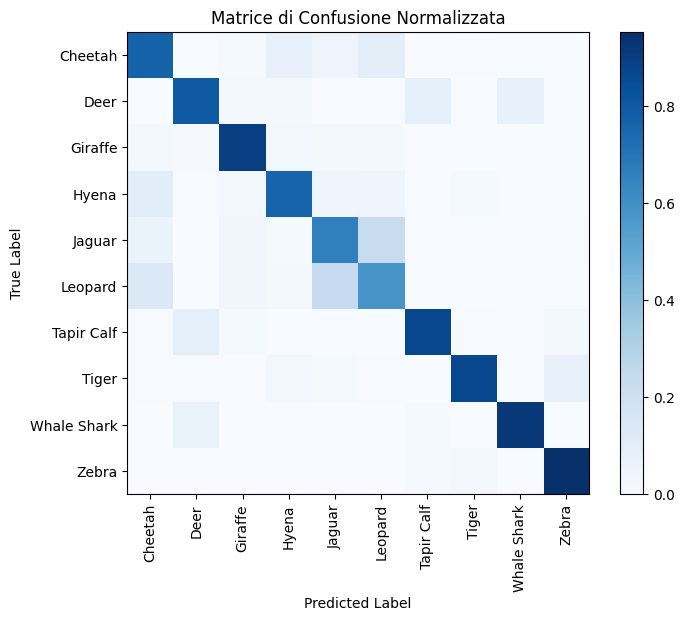

In [30]:
# VALUTAZIONE DELLA CNN SUL TEST SET E VISUALIZZAZIONE DEI RISULTATI

predizioni = CNN(X_test_tensor)
predizioni_classe = torch.argmax(predizioni, dim=1)
accuracy = (predizioni_classe == y_test_tensor).float().mean()
print(f'Accuracy sul test set: {accuracy*100:.4f}%')
confusion_matrix = torch.zeros(10, 10, dtype=torch.int32)
for true, pred in zip(y_test_tensor, predizioni_classe):
    confusion_matrix[true, pred] += 1
normalized_confusion_matrix = confusion_matrix.float() / confusion_matrix.sum(dim=1, keepdim=True)
plt.figure(figsize=(8, 6))
plt.imshow(normalized_confusion_matrix, cmap='Blues')
plt.title('Matrice di Confusione Normalizzata')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(np.arange(10), etic.values(),rotation = 90)
plt.yticks(np.arange(10), etic.values())
plt.show()

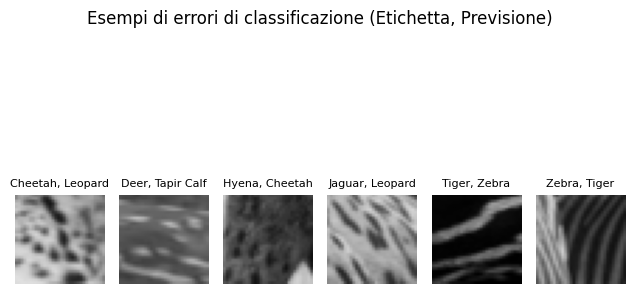

In [31]:
#errori di classificazione
errori = zip(y_test,predizioni_classe.numpy(),range(10000))
errori = [err for err in errori if err[0]!=err[1]]

fig = plt.figure()
ax = fig.add_subplot(1, 6, 1)
ax.set_axis_off()
ax.imshow(X_test[errori[0][2]],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[errori[0][0]]}, {etic[errori[0][1]]}',fontsize=8 )

ax = fig.add_subplot(1, 6, 2)
ax.set_axis_off()
ax.imshow(X_test[errori[400][2]],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[errori[400][0]]}, {etic[errori[400][1]]}' ,fontsize=8)

ax = fig.add_subplot(1,6, 3)
ax.set_axis_off()
ax.imshow(X_test[errori[560][2]],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[errori[560][0]]}, {etic[errori[560][1]]}' ,fontsize=8)

ax = fig.add_subplot(1,6, 4)
ax.set_axis_off()
ax.imshow(X_test[errori[-1000][2]],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[errori[-1000][0]]}, {etic[errori[-1000][1]]}' ,fontsize=8)

ax = fig.add_subplot(1,6, 5)
ax.set_axis_off()
ax.imshow(X_test[errori[-300][2]],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[errori[-130][0]]}, {etic[errori[-130][1]]}',fontsize=8 )

ax = fig.add_subplot( 1,6, 6)
ax.set_axis_off()
ax.imshow(X_test[errori[-1][2]],cmap='gray', vmin=0.0, vmax=1.0)
ax.set_title(f'{etic[errori[-1][0]]}, {etic[errori[-1][1]]}',fontsize=8 )

plt.tight_layout()
fig.suptitle('Esempi di errori di classificazione (Etichetta, Previsione)')
plt.show()

In [15]:
# CREAZIONE RETE FEEDFORWARD PER CONFRONTO CON LA CNN SULLO STESSO DATASET

# Appiattimento dei dati

encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_train=y_train.reshape(-1, 1)
y_train_one_hot = encoder.fit_transform(y_train)
y_test=y_test.reshape(-1, 1)
y_test_one_hot = encoder.transform(y_test)

D_train = list(zip(X_train.reshape(-1, righe*col), y_train_one_hot))
D_test = list(zip(X_test.reshape(-1, righe*col), y_test_one_hot))

Addestramento Adam:   0%|          | 0/21 [00:00<?, ?it/s]C:\Users\CdC\AppData\Local\Temp\ipykernel_17232\2929616767.py:145: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
Addestramento Adam: 100%|██████████| 21/21 [49:53<00:00, 142.54s/it, Loss=1.922237]


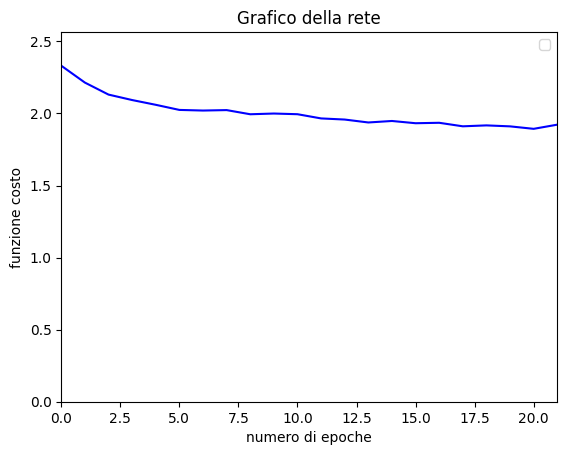

In [16]:
# CREAZIONE E ADDESTRAMENTO ADAM RETE

NNadam=feedforwardNN([righe*col, 256, 128 ,10], 'softmax', 'relu', 'cross entropy')
NNadam.Adam( training_set = D_train, epochs=21, mini_batch_size=32, eta=0.001, test_set=D_test, plot_progress=False)



Addestramento MLP:   0%|          | 0/21 [00:00<?, ?it/s]C:\Users\CdC\AppData\Local\Temp\ipykernel_17232\2929616767.py:265: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
Addestramento MLP: 100%|██████████| 21/21 [43:30<00:00, 124.29s/it, Loss=2.071075]

Training completato!


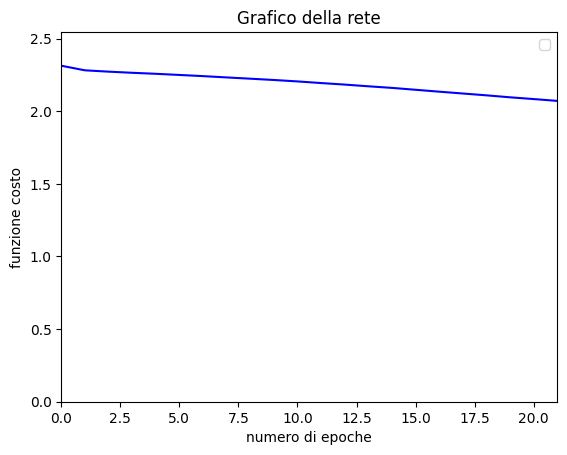

In [17]:
# CREAZIONE E ADDESTRAMENTO SGD RETE

NNsgd=feedforwardNN([righe*col, 256, 128 ,10], 'softmax', 'relu', 'cross entropy')
NNsgd.sgd( training_set = D_train, epochs=21, mini_batch_size=32, eta=0.001, test_set=D_test, plot_progress=False)

Accuracy sul test set: 31.3000%


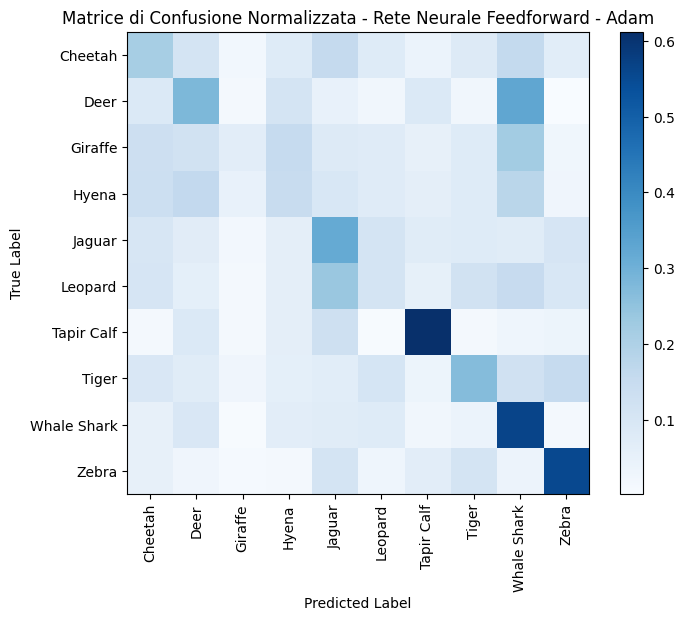

In [18]:
# VALUTAZIONE RETE FFN CON ADAM

y_true, y_pred = NNadam.get_predictions(D_test)

# Convertiamo le probabilità e le etichette one-hot in indici interi di classe
y_true_labels = np.argmax(np.array(y_true), axis=1)
y_pred_labels = np.argmax(np.array(y_pred), axis=1)

accuracy_ffn_adam= np.mean(y_true_labels == y_pred_labels)
print(f'Accuracy sul test set: {accuracy_ffn_adam*100:.4f}%')
confusion_matrix_ffn_adam = np.zeros((10, 10), dtype=int)
for true, pred in zip(y_true_labels, y_pred_labels):
    confusion_matrix_ffn_adam[true, pred] += 1
normalized_confusion_matrix_ffn_adam = confusion_matrix_ffn_adam / confusion_matrix_ffn_adam.sum(axis=1, keepdims=True)
plt.figure(figsize=(8, 6))
plt.imshow(normalized_confusion_matrix_ffn_adam, cmap='Blues')
plt.title('Matrice di Confusione Normalizzata - Rete Neurale Feedforward - Adam')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(np.arange(10), etic.values(),rotation = 90)
plt.yticks(np.arange(10), etic.values())
plt.show()


Accuracy sul test set: 27.0000%


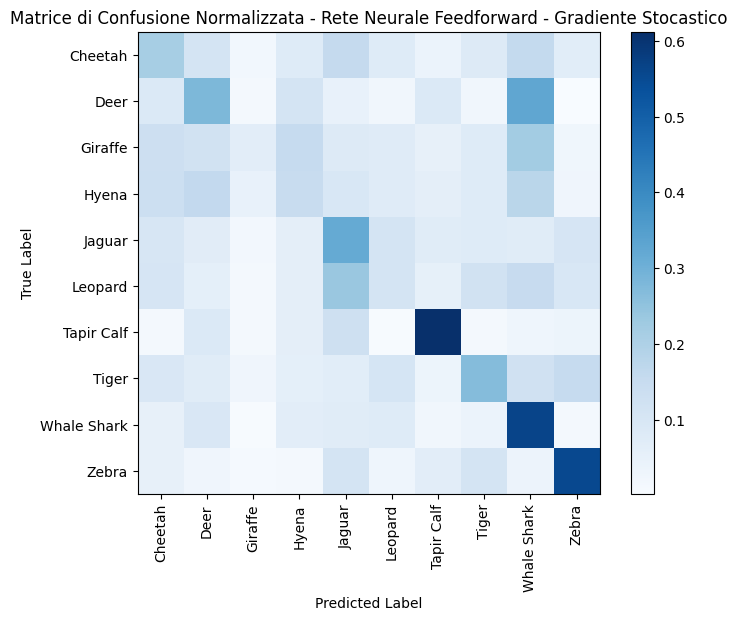

In [19]:
# VALUTAZIONE RETE FFN CON SGD

y_true, y_pred = NNsgd.get_predictions(D_test)

# Convertiamo le probabilità e le etichette one-hot in indici interi di classe
y_true_labels = np.argmax(np.array(y_true), axis=1)
y_pred_labels = np.argmax(np.array(y_pred), axis=1)

accuracy_ffn_sgd= np.mean(y_true_labels == y_pred_labels)
print(f'Accuracy sul test set: {accuracy_ffn_sgd*100:.4f}%')
confusion_matrix_ffn_sgd = np.zeros((10, 10), dtype=int)
for true, pred in zip(y_true_labels, y_pred_labels):
    confusion_matrix_ffn_sgd[true, pred] += 1
normalized_confusion_matrix_ffn_sgd = confusion_matrix_ffn_sgd / confusion_matrix_ffn_sgd.sum(axis=1, keepdims=True)
plt.figure(figsize=(8, 6))
plt.imshow(normalized_confusion_matrix_ffn_adam, cmap='Blues')
plt.title('Matrice di Confusione Normalizzata - Rete Neurale Feedforward - Gradiente Stocastico')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(np.arange(10), etic.values(),rotation = 90)
plt.yticks(np.arange(10), etic.values())
plt.show()

In [9]:
# CREAZIONE DATASET PER REGRESSIONE 

x=np.random.uniform(low=0.0, high=35.0, size=(1500, 1)) # 1500 campioni di input casuali tra 0 e 35
y=np.log(20*x**2+5)-11*(np.sin(3/2*np.sqrt(x)))**2-np.random.normal(scale = 1.2,size = (1500,1))
y_normalize = (y - y.mean()) / y.std()  # Output lineare con rumore
D_reg_train = list(zip(x, y_normalize))

x_test=np.random.uniform(low=0.0, high=35.0, size=(300, 1))   # 300 campioni di input casuali tra 0 e 35
y_test=np.log(20*x_test**2+5)-11*(np.sin(3/2*np.sqrt(x_test)))**2-np.random.normal(scale = 1.2,size = (300,1))
y_test_normalize = (y_test - y.mean()) / y.std()  # Usa media e deviazione del TRAINING set
D_reg_test = list(zip(x_test, y_test_normalize))


Addestramento con learning rate=0.001 e attivazione nascosta=tanh


Addestramento Adam:   0%|          | 0/75 [00:00<?, ?it/s]C:\Users\CdC\AppData\Local\Temp\ipykernel_9988\2929616767.py:145: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
Addestramento Adam: 100%|██████████| 75/75 [00:12<00:00,  5.89it/s, Loss=0.050879]


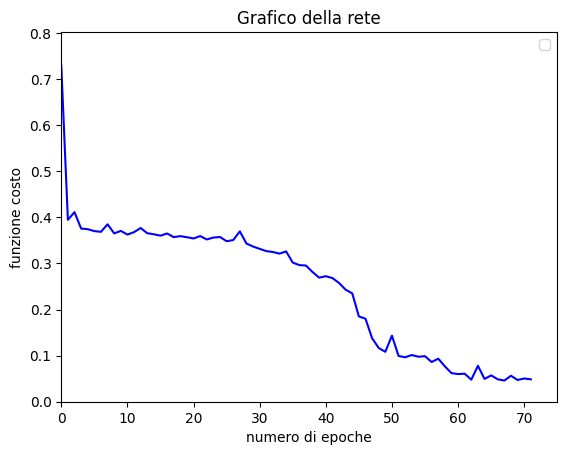

Addestramento Adam: 100%|██████████| 75/75 [00:13<00:00,  5.64it/s, Loss=0.047238]


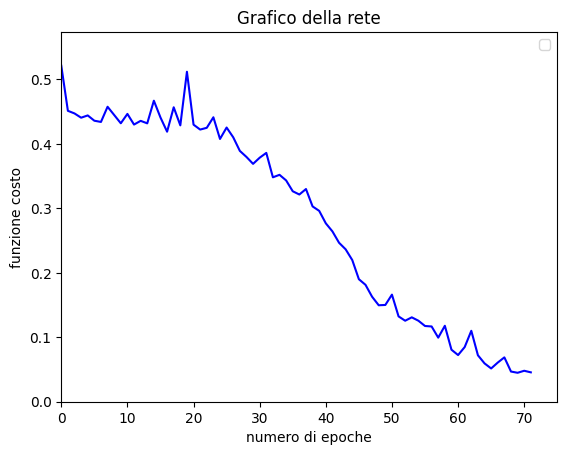

Addestramento Adam: 100%|██████████| 75/75 [00:13<00:00,  5.73it/s, Loss=0.055016]


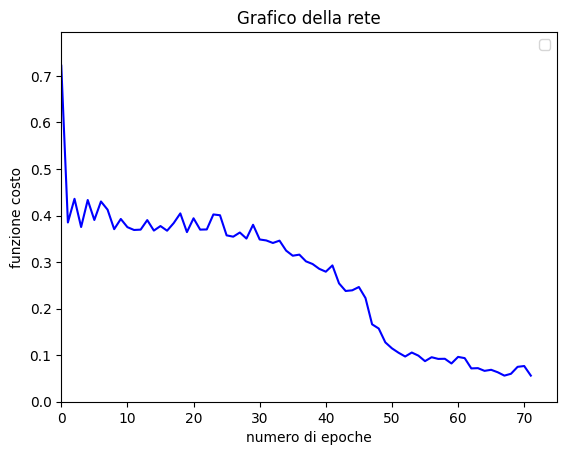

Addestramento Adam: 100%|██████████| 75/75 [00:13<00:00,  5.71it/s, Loss=0.042929]


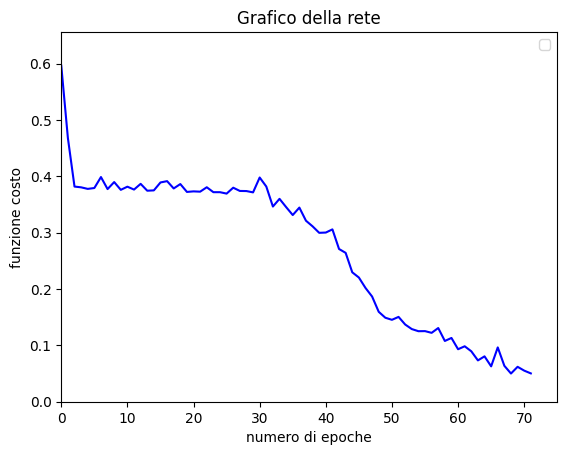

Addestramento Adam: 100%|██████████| 75/75 [00:13<00:00,  5.73it/s, Loss=0.047118]


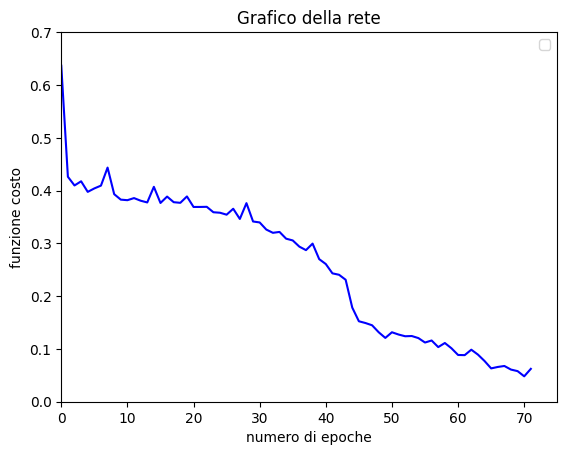

Addestramento Adam: 100%|██████████| 75/75 [00:13<00:00,  5.72it/s, Loss=0.041506]


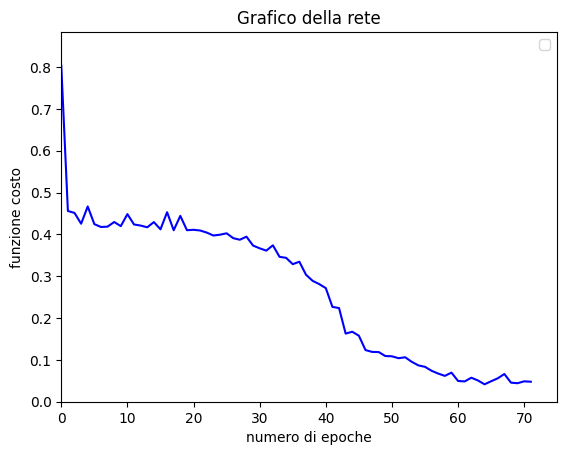

Addestramento Adam: 100%|██████████| 75/75 [00:12<00:00,  6.11it/s, Loss=0.047345]


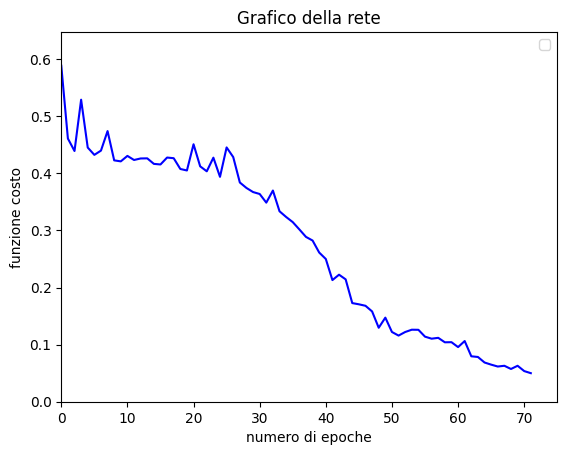

Addestramento Adam: 100%|██████████| 75/75 [00:12<00:00,  6.08it/s, Loss=0.057343]


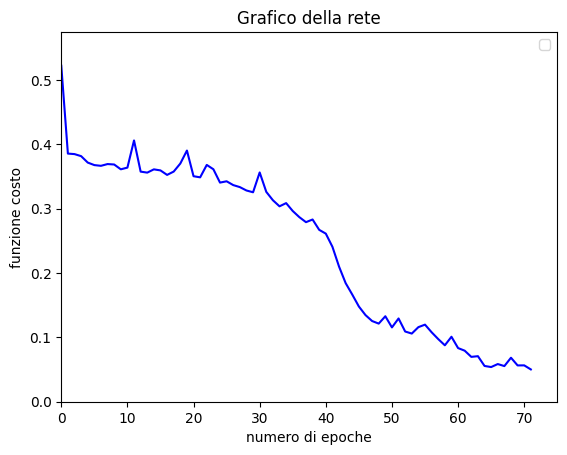

Addestramento Adam: 100%|██████████| 75/75 [00:12<00:00,  6.07it/s, Loss=0.056512]


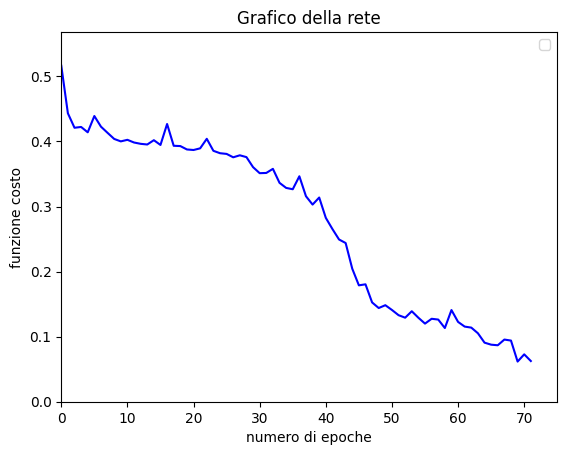

Addestramento Adam: 100%|██████████| 75/75 [00:12<00:00,  6.03it/s, Loss=0.067000]


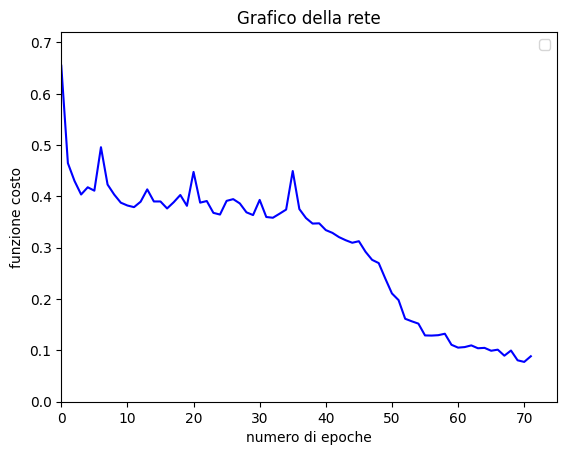

Mean MSE per learning rate=0.001 e attivazione nascosta=tanh: 0.1026
Addestramento con learning rate=0.001 e attivazione nascosta=sigmoid


Addestramento Adam: 100%|██████████| 75/75 [00:14<00:00,  5.02it/s, Loss=0.362049]


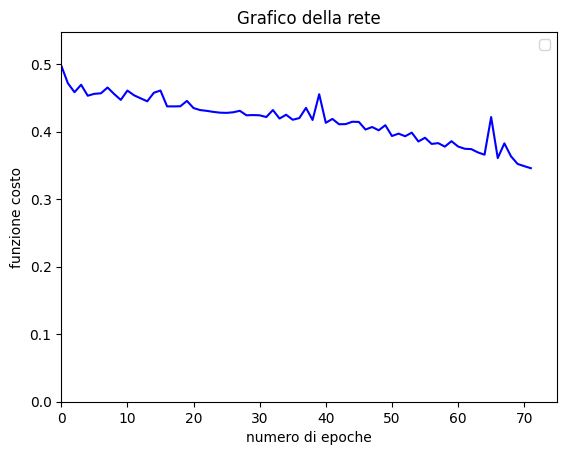

Addestramento Adam: 100%|██████████| 75/75 [00:15<00:00,  4.94it/s, Loss=0.282036]


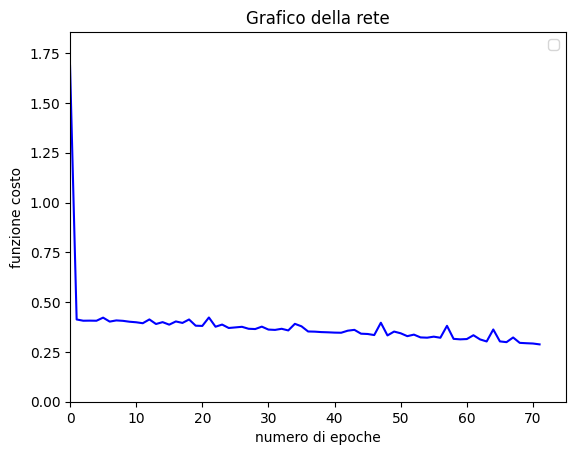

Addestramento Adam: 100%|██████████| 75/75 [00:15<00:00,  4.90it/s, Loss=0.296699]


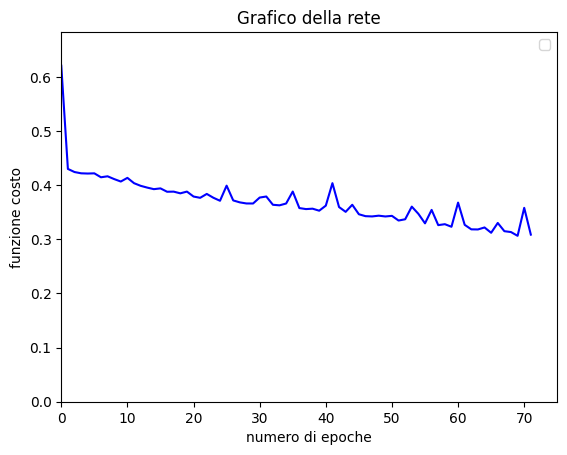

Addestramento Adam: 100%|██████████| 75/75 [00:16<00:00,  4.58it/s, Loss=0.331217]


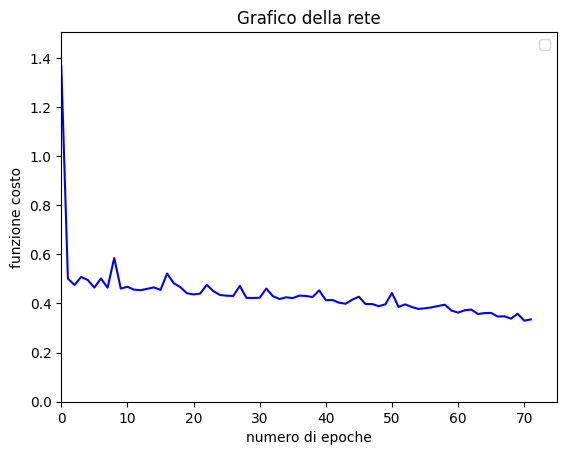

Addestramento Adam: 100%|██████████| 75/75 [00:15<00:00,  4.72it/s, Loss=0.302509]


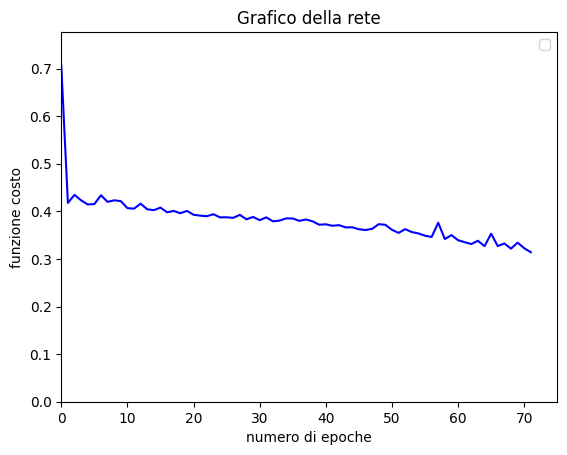

Addestramento Adam: 100%|██████████| 75/75 [00:16<00:00,  4.63it/s, Loss=0.312260]


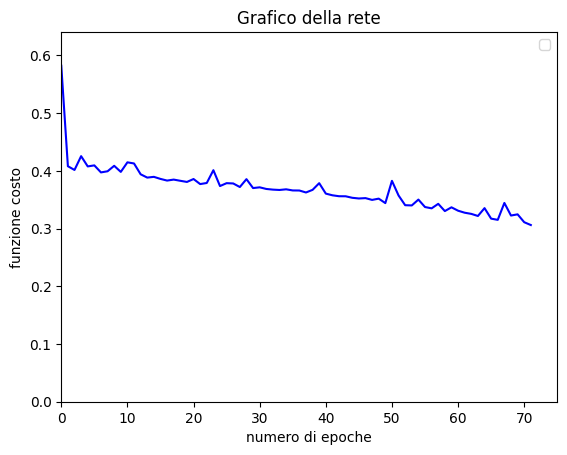

Addestramento Adam: 100%|██████████| 75/75 [00:16<00:00,  4.51it/s, Loss=0.276592]


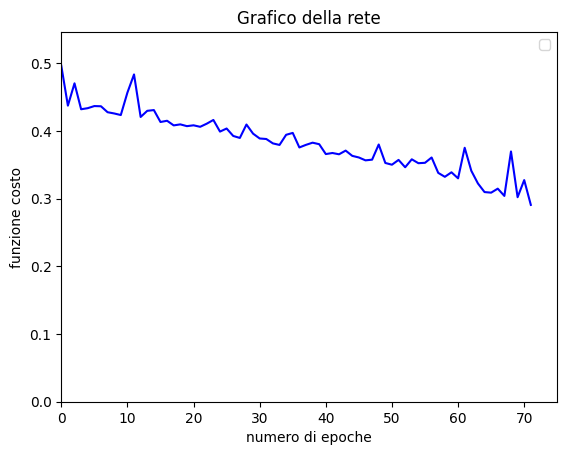

Addestramento Adam: 100%|██████████| 75/75 [00:17<00:00,  4.41it/s, Loss=0.289534]


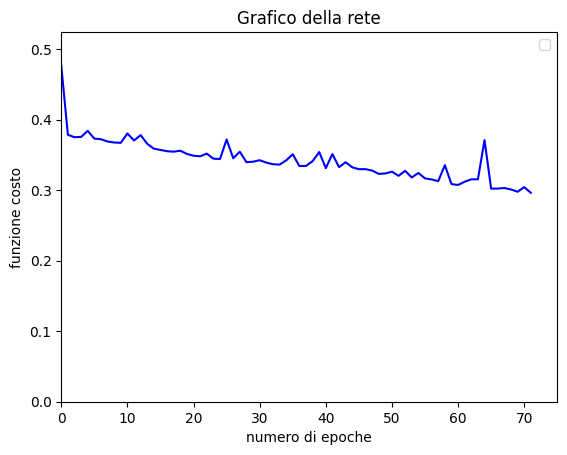

Addestramento Adam: 100%|██████████| 75/75 [00:16<00:00,  4.56it/s, Loss=0.305852]


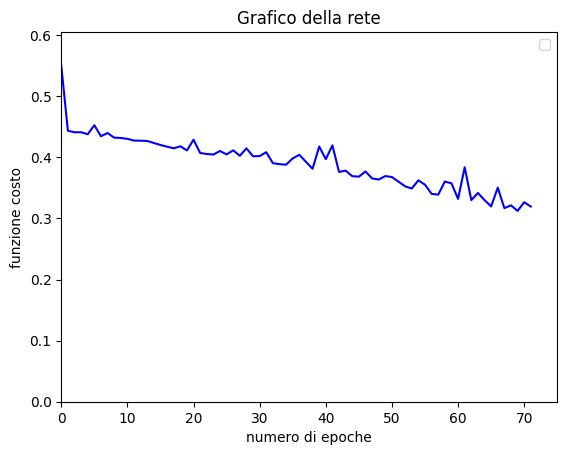

Addestramento Adam: 100%|██████████| 75/75 [00:15<00:00,  4.93it/s, Loss=0.377576]


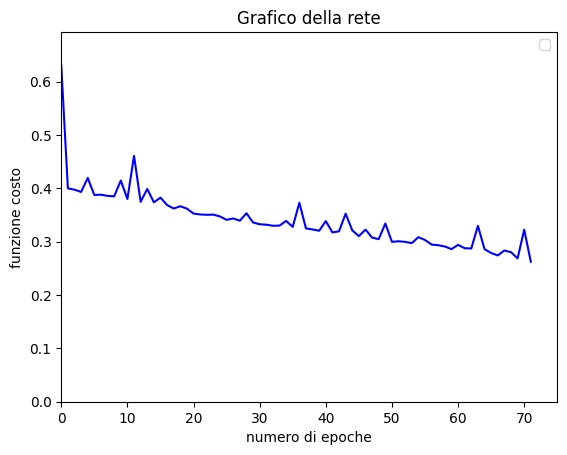

Mean MSE per learning rate=0.001 e attivazione nascosta=sigmoid: 0.6273
Addestramento con learning rate=0.0001 e attivazione nascosta=tanh


Addestramento Adam: 100%|██████████| 75/75 [00:12<00:00,  6.03it/s, Loss=0.417220]


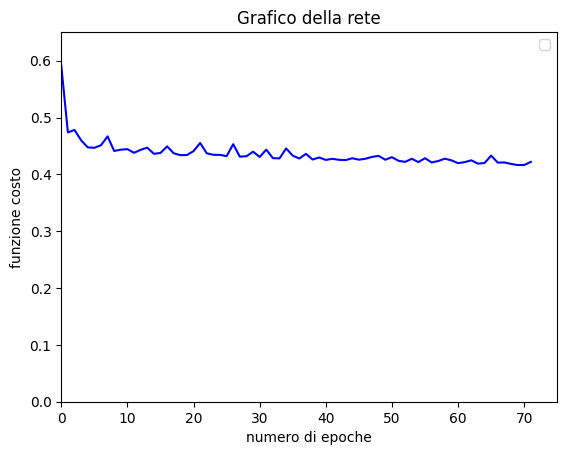

Addestramento Adam: 100%|██████████| 75/75 [00:12<00:00,  6.03it/s, Loss=0.393124]


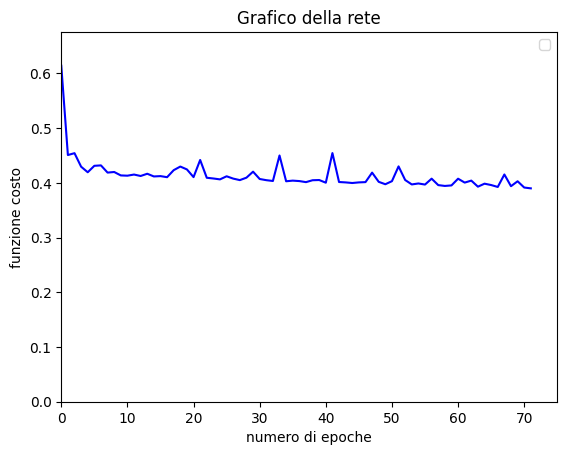

Addestramento Adam: 100%|██████████| 75/75 [00:12<00:00,  6.02it/s, Loss=0.375873]


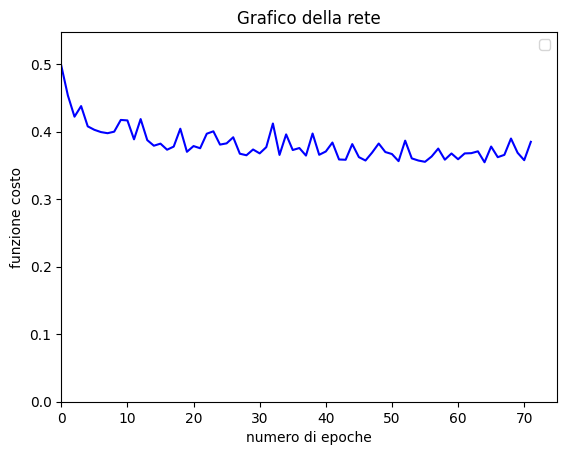

Addestramento Adam: 100%|██████████| 75/75 [00:12<00:00,  5.99it/s, Loss=0.357183]


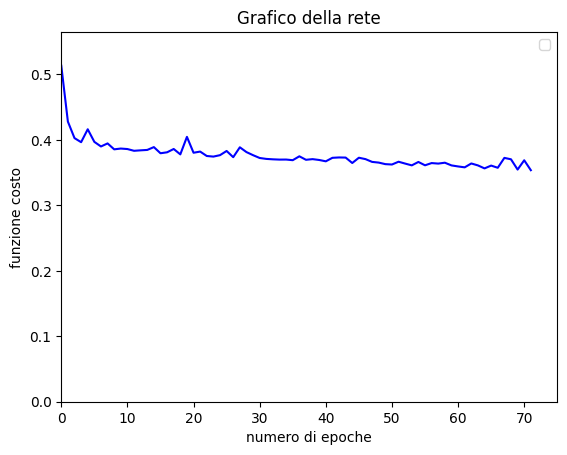

Addestramento Adam: 100%|██████████| 75/75 [00:12<00:00,  6.01it/s, Loss=0.369127]


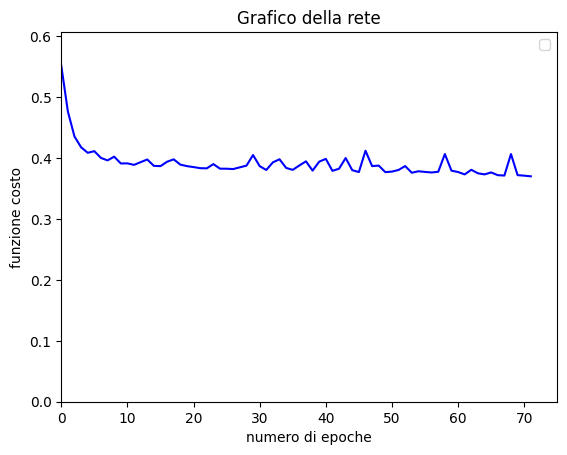

Addestramento Adam: 100%|██████████| 75/75 [00:12<00:00,  5.96it/s, Loss=0.366162]


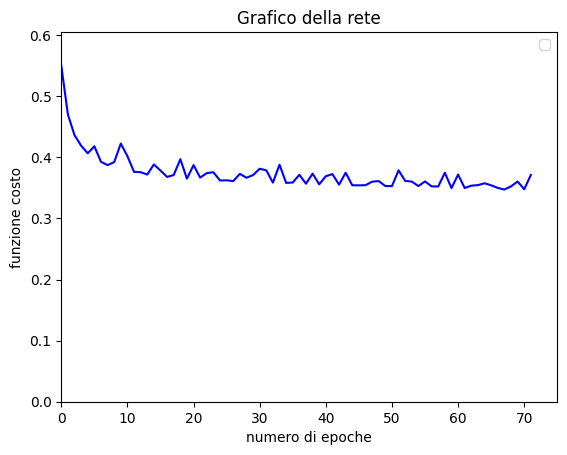

Addestramento Adam: 100%|██████████| 75/75 [00:12<00:00,  5.78it/s, Loss=0.365026]


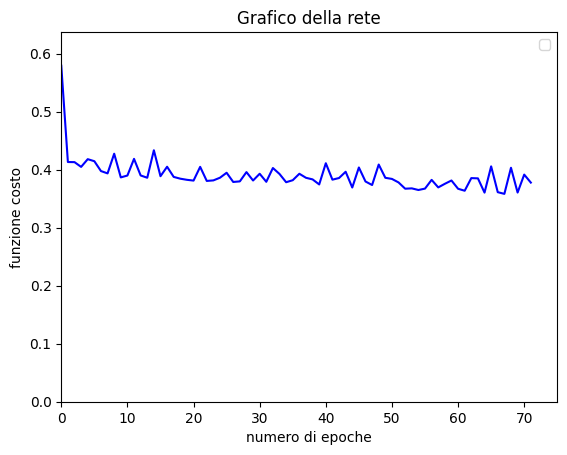

Addestramento Adam: 100%|██████████| 75/75 [00:13<00:00,  5.50it/s, Loss=0.435103]


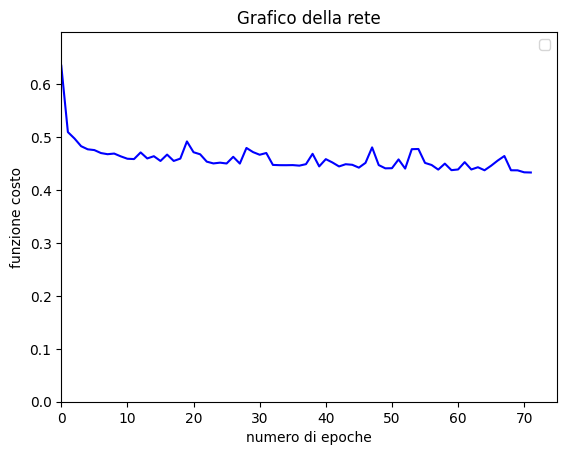

Addestramento Adam: 100%|██████████| 75/75 [00:13<00:00,  5.69it/s, Loss=0.374394]


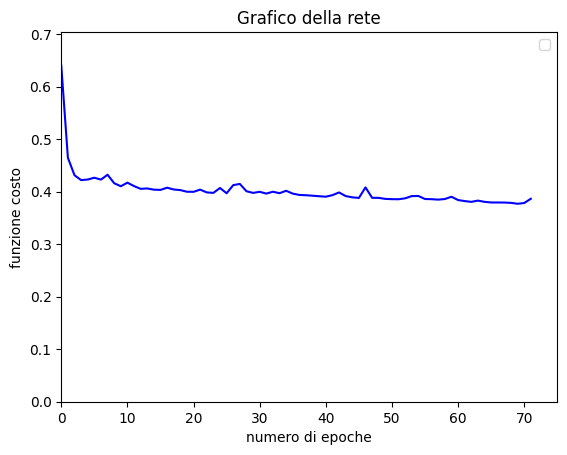

Addestramento Adam: 100%|██████████| 75/75 [00:14<00:00,  5.14it/s, Loss=0.386739]


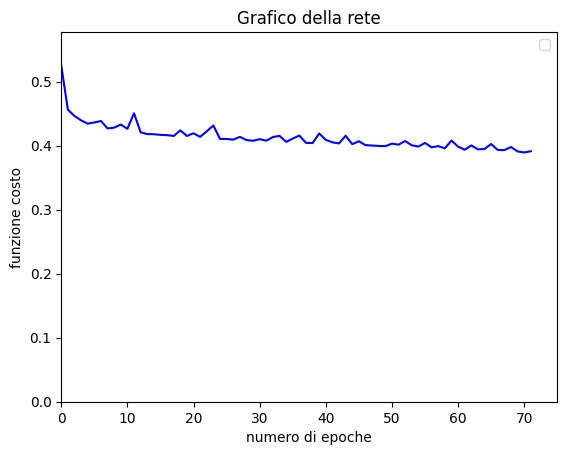

Mean MSE per learning rate=0.0001 e attivazione nascosta=tanh: 0.7680
Addestramento con learning rate=0.0001 e attivazione nascosta=sigmoid


Addestramento Adam: 100%|██████████| 75/75 [00:16<00:00,  4.43it/s, Loss=0.421699]


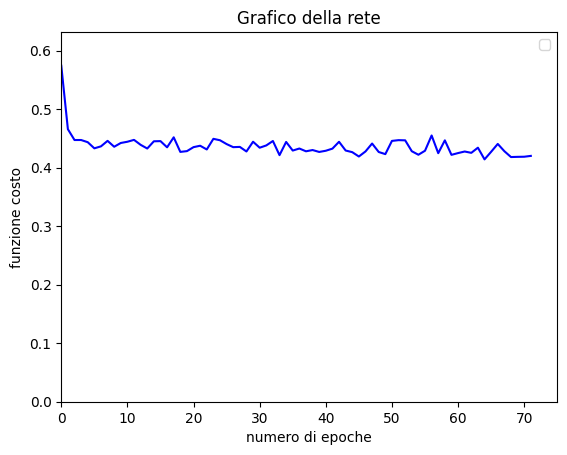

Addestramento Adam: 100%|██████████| 75/75 [00:16<00:00,  4.55it/s, Loss=0.393094]


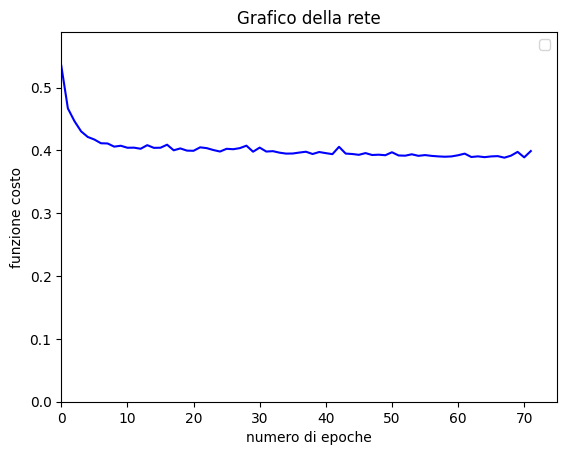

Addestramento Adam: 100%|██████████| 75/75 [00:16<00:00,  4.49it/s, Loss=0.450590]


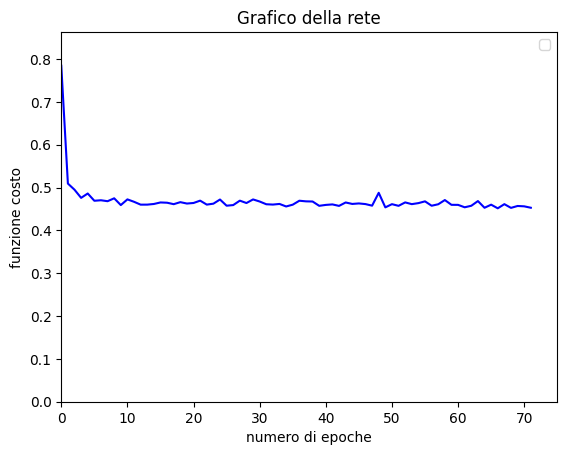

Addestramento Adam: 100%|██████████| 75/75 [00:16<00:00,  4.45it/s, Loss=0.422444]


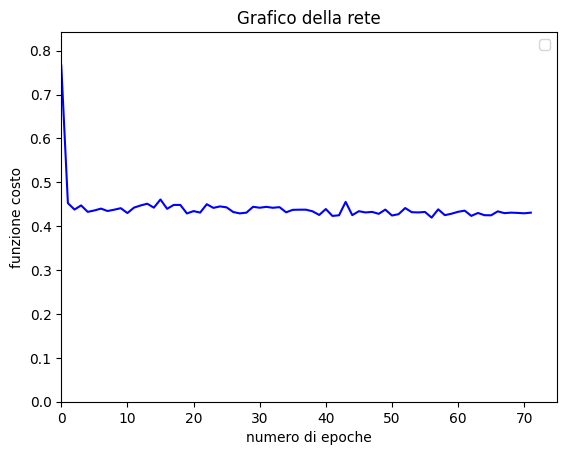

Addestramento Adam: 100%|██████████| 75/75 [00:17<00:00,  4.40it/s, Loss=0.403087]


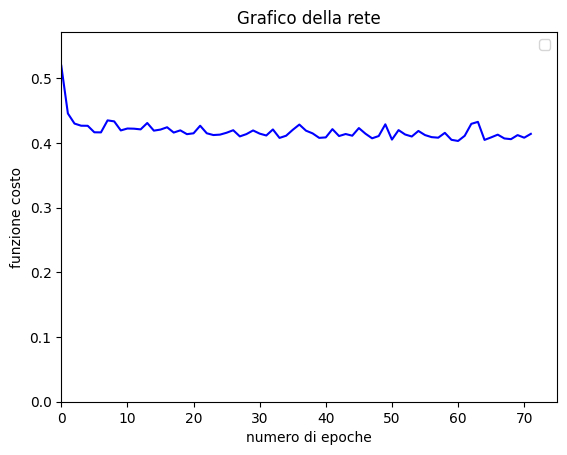

Addestramento Adam: 100%|██████████| 75/75 [00:16<00:00,  4.49it/s, Loss=0.415107]


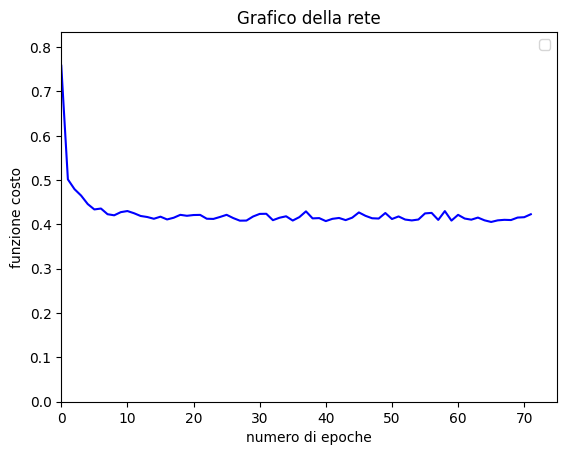

Addestramento Adam: 100%|██████████| 75/75 [00:20<00:00,  3.65it/s, Loss=0.417199]


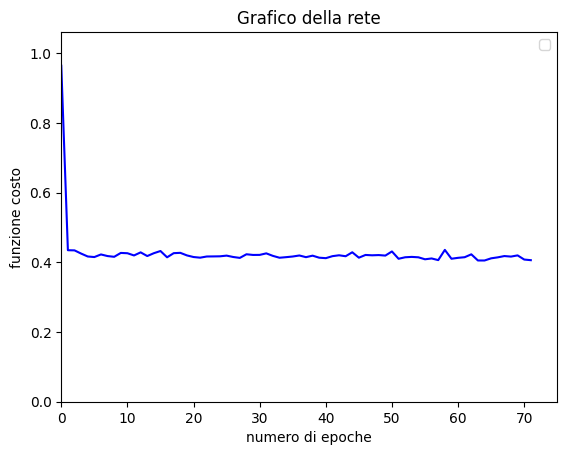

Addestramento Adam: 100%|██████████| 75/75 [00:17<00:00,  4.21it/s, Loss=0.401339]


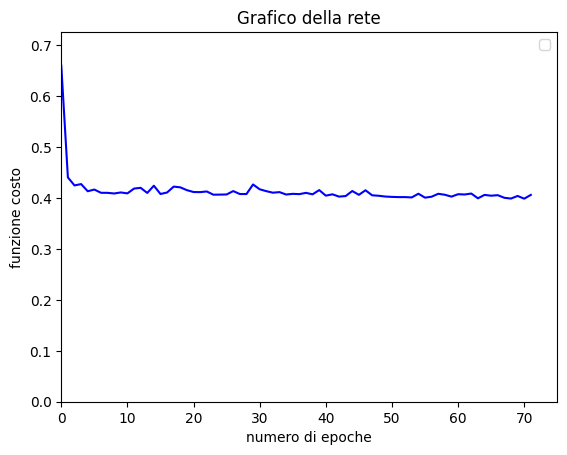

Addestramento Adam: 100%|██████████| 75/75 [00:17<00:00,  4.30it/s, Loss=0.422200]


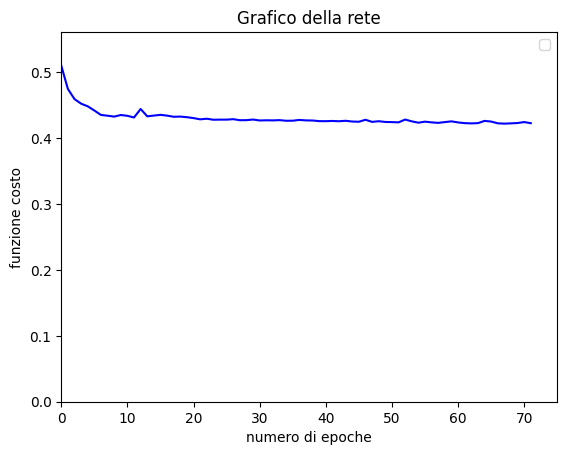

Addestramento Adam: 100%|██████████| 75/75 [00:16<00:00,  4.45it/s, Loss=0.400548]


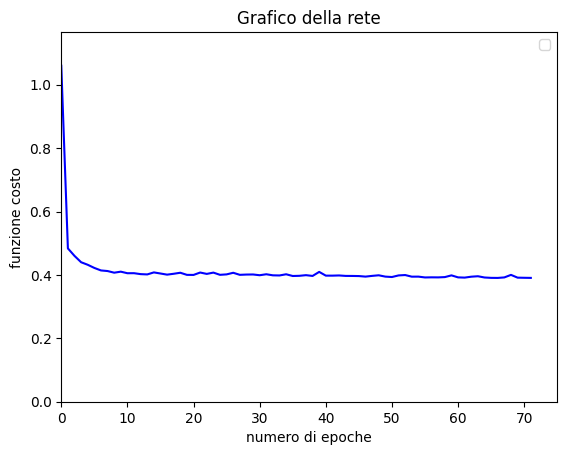

Mean MSE per learning rate=0.0001 e attivazione nascosta=sigmoid: 0.8295
Migliori parametri: learning rate=0.001, attivazione nascosta=tanh, MSE=0.1026


In [10]:
# SCELTA IPERPARAMETRI TRAMITE CROSS-VALIDATION (K=10)

import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import OneHotEncoder
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import random
import pickle
import itertools

lr=[0.001, 0.0001]
hidden_activations=['tanh', 'sigmoid']
best_mse=float('inf')
best_params=None

for eta, hidden_activation in itertools.product(lr, hidden_activations):
    print(f'Addestramento con learning rate={eta} e attivazione nascosta={hidden_activation}')
    fold_mses = []
    
    # 1. Utilizziamo il dataset di regressione corretto e iteriamo sul generatore
    for train_fold, test_fold in cross_validation(D_reg_train.copy(), k_folds=10):
        # 2. Inizializziamo la rete ad ogni fold per evitare il "data leakage" (mantenimento dei pesi)
        nn_regression = feedforwardNN([1, 256, 128, 1], 'linear', hidden_activation, 'mse')
        nn_regression.Adam(train_fold, epochs=75, mini_batch_size=32, eta=eta, test_set=test_fold, plot_progress=False)
        
        y_true, y_pred = nn_regression.get_predictions(test_fold)
        fold_mses.append(np.mean((np.array(y_true) - np.array(y_pred))**2))
        
    # 3. Media degli MSE dei vari fold
    mean_mse = np.mean(fold_mses)
    print(f'Mean MSE per learning rate={eta} e attivazione nascosta={hidden_activation}: {mean_mse:.4f}')
    if mean_mse < best_mse:
        best_mse = mean_mse
        best_params = (eta, hidden_activation)

print(f'Migliori parametri: learning rate={best_params[0]}, attivazione nascosta={best_params[1]}, MSE={best_mse:.4f}')

Addestramento Adam:   0%|          | 0/150 [00:00<?, ?it/s]C:\Users\CdC\AppData\Local\Temp\ipykernel_9988\2929616767.py:145: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
Addestramento Adam: 100%|██████████| 150/150 [00:28<00:00,  5.36it/s, Loss=0.043109]


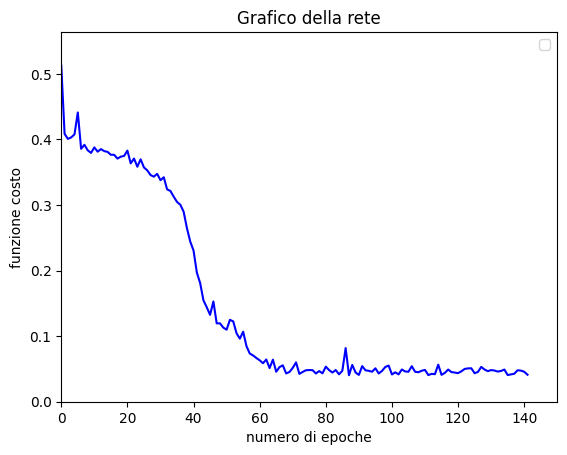

In [14]:
# CREAZIONE E ADDETRAMENTO RETE FFN

nn_regression = feedforwardNN([1, 256, 128, 1], 'linear', best_params[1], 'mse')
nn_regression.Adam(D_reg_train, epochs=150, mini_batch_size=32, eta=best_params[0], test_set=D_reg_test, plot_progress=False)

MSE sul test set: 1.5256
Devianza: 30.1518
R^2: 0.9120


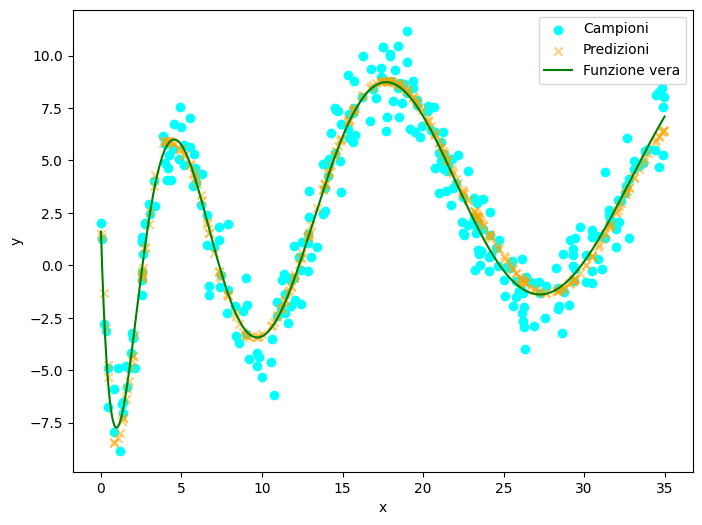

In [15]:
# VALUTAZIONE RETE 

y_true, y_pred = nn_regression.get_predictions(D_reg_test)
y_true_denormalized = np.array(y_true) * y.std() + y.mean()
y_pred_denormalized = np.array(y_pred) * y.std() + y.mean()
mse = np.mean((y_true_denormalized - y_pred_denormalized)**2)
dev = np.sum( ((np.log(20*x_test**2+5)-11*(np.sin(3/2*np.sqrt(x_test)))**2)-y_pred_denormalized)**2 )
TSS = np.mean((y_true_denormalized -np.mean(y_true_denormalized))**2)
print(f'MSE sul test set: {mse:.4f}')
print(f'Devianza: {dev:.4f}')
R2 = 1-mse/TSS
print(f'R^2: {R2:.4f}')
plt.figure(figsize=(8, 6))
plt.scatter(x_test, y_test, label='Campioni', color='cyan')
plt.scatter(x_test, y_pred_denormalized, label='Predizioni', color='orange', alpha=0.5,marker='x')
x_graf = np.linspace(0,35,10000)
y_graf = np.array(np.log(20*x_graf**2+5)-11*(np.sin(3/2*np.sqrt(x_graf)))**2)
plt.plot(x_graf,y_graf,label='Funzione vera',color='green')
#plt.title('Predizioni vs Dati Reali - Rete Neurale Feedforward per Regressione')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()